In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_meteo_df = pd.read_parquet("../data/raw/meteo_data.parquet")
df = raw_meteo_df.copy()

In [3]:
df.head()

,temperature_2m,wind_speed_100m,cloud_cover,location,datetime
0,10.5,11.6,31,City_Sevilla,2023-01-01 00:00:00+00:00
1,10.1,12.5,55,City_Sevilla,2023-01-01 01:00:00+00:00
2,10.0,14.6,59,City_Sevilla,2023-01-01 02:00:00+00:00
3,10.0,16.1,58,City_Sevilla,2023-01-01 03:00:00+00:00
4,9.8,15.9,62,City_Sevilla,2023-01-01 04:00:00+00:00


In [4]:
df["datetime"].min()

Timestamp('2023-01-01 00:00:00+0000', tz='UTC')

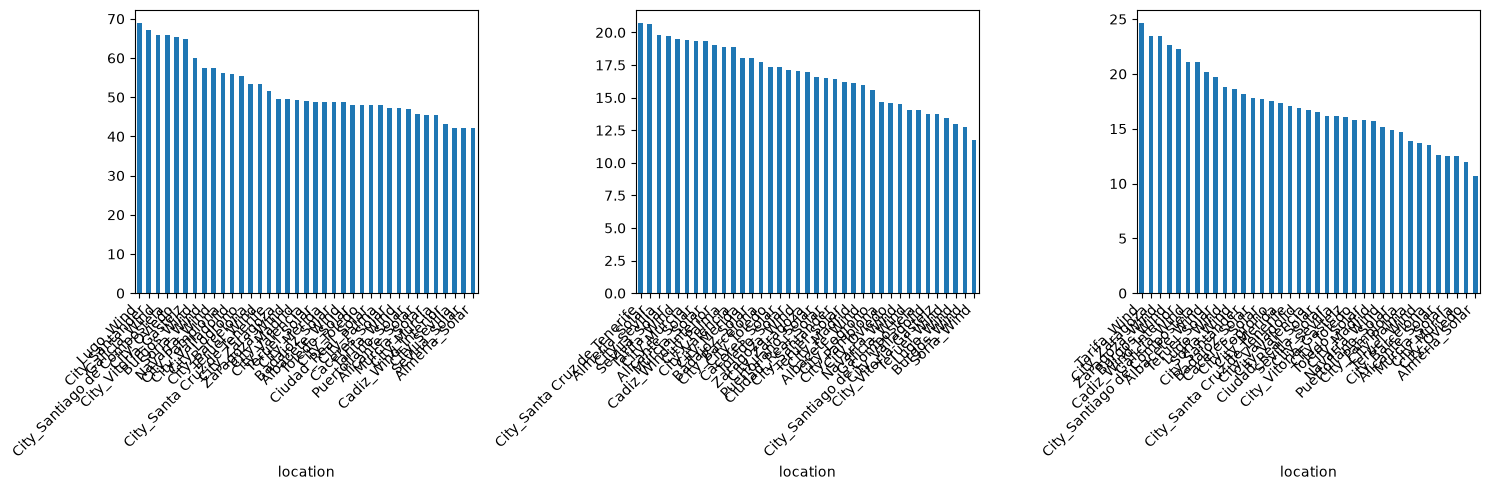

In [5]:
fig, plots = plt.subplots(1, 3, figsize=(15, 5))

(
    df.groupby("location")["cloud_cover"]
    .mean()
    .sort_values(ascending=False)
).plot.bar(
    ax=plots[0]
)

(
    df.groupby("location")["temperature_2m"]
    .mean()
    .sort_values(ascending=False)
).plot.bar(
    ax=plots[1]
)

(
    df.groupby("location")["wind_speed_100m"]
    .mean()
    .sort_values(ascending=False)
).plot.bar(
    ax=plots[2]
)

for plot in plots:
    for label in plot.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

plt.tight_layout()
plt.show()